In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [4]:
df = pd.read_csv("/content/spam.csv",encoding="latin-1")

df = df[['v1','v2']]
df.columns = ["label","message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df['label'] = df['label'].map({'ham':0,'spam':1})

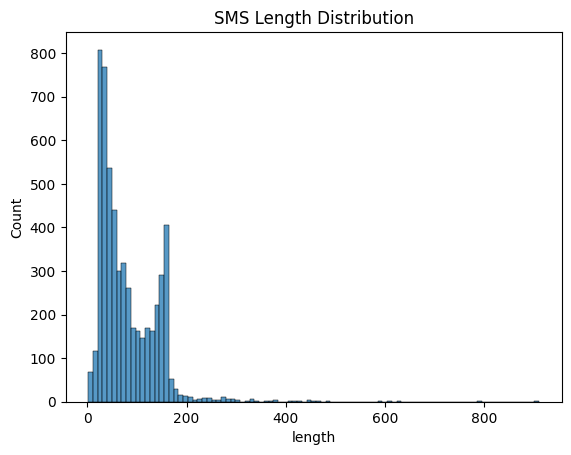

In [6]:
df['length'] = df['message'].apply(len)

sns.histplot(df['length'])

plt.title("SMS Length Distribution")

plt.show()

In [7]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(df['message'])
y = df['label']

In [8]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [9]:
models = {

"Naive Bayes": MultinomialNB(),
"Logistic Regression": LogisticRegression(),
"SVM": LinearSVC()

}

results = {}

for name,model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    results[name] = acc

    print(name)
    print(classification_report(y_test,pred))

Naive Bayes
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.81      0.90       150

    accuracy                           0.97      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.97      0.64      0.77       150

    accuracy                           0.95      1115
   macro avg       0.96      0.82      0.87      1115
weighted avg       0.95      0.95      0.94      1115

SVM
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.96      0.84      0.90       150

    accuracy                           0.97      1115
   macro avg       0.97      0.92      0.94      1115
weighted avg       0.97      0.97     

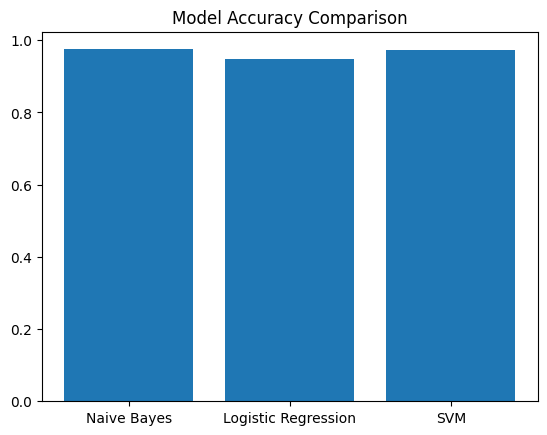

In [10]:
plt.bar(results.keys(),results.values())

plt.title("Model Accuracy Comparison")

plt.show()

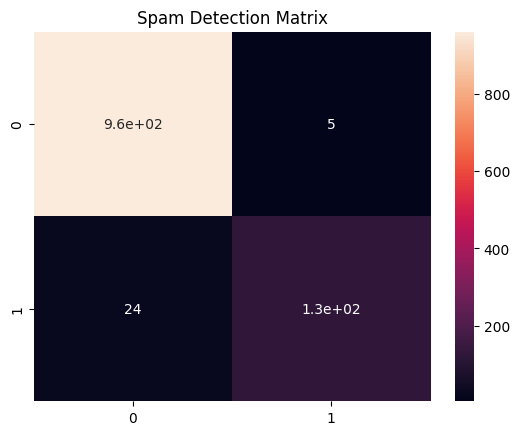

In [11]:
model = LinearSVC()

model.fit(X_train,y_train)

pred = model.predict(X_test)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True)

plt.title("Spam Detection Matrix")

plt.show()